# Another Power Spectrum Example

This notebook shows an example of how to generate a Gaussian random vector field with a power spectrum model, and compute its 1D and 3D power spectra. It also shows how to compare the 1D power spectrum computed from the 3D power spectrum with the one computed directly from the power spectrum model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad_vec
from kspace import FourierAnalysis, GaussianRandomField, PowerLawBetaModel

We set up our power spectrum model using the `PowerLawBetaModel` class, which has the following functional form:

In [2]:
l_min = 10.0  # minimum or "dissipation" scale
l_max = 200.0  # maximum or "injection" scale
alpha = -11.0 / 3.0
f_rms = 10.0  # normalization of the field

In [3]:
power_spec = PowerLawBetaModel(l_min, l_max, alpha)

and we normalize it:

In [4]:
# Renormalize the power spectra to have the desired RMS value
power_spec.renormalize(f_rms)

Next, we set up the Gaussian random field generator, and generate a scalar field realization:


In [5]:
# Parameters for the box and grid
le = np.array([0.0, 0.0, 0.0])
re = np.array([750.0, 750.0, 750.0])
ddims = [256] * 3
width = re - le

In [6]:
# This makes a Gaussian random field with the specified power spectrum
g = GaussianRandomField(le, re, ddims, power_spec, seed=20)
s = g.generate_scalar_field_realization()

Now we can show how to take the power spectrum of the field in 3D, derive its 1D power spectrum along the x-direction, and compare it to theactual power spectra of both fields and compare them to their input power spectra. First, we create an instance of the `FourierAnalysis` class, which will help us with these tasks.


In [7]:
# Give the FourierAnalysis class the same width and dims as
# the GaussianRandomField created above
fa = FourierAnalysis(width, ddims)

We can take the scalar field `s` and compute its 3D power spectrum $P_{\rm 3D}({\bf k})$ using the `make_powerspec` method:

In [8]:
P_3D = fa.make_powerspec(s)
print(P_3D.shape)

(256, 256, 256)


To get the 1-dimensional power spectrum for just one direction, integrated over the other two directions, we can use the `integrate_kspace` method of the `FourierAnalysis` class, and choose the axes we want to integrate over. If we choose `axis=(1,2)`, this will give us the 1D power spectrum along the x-direction. This is equivalent to performing this integral:

$$P_{\rm 1D}(k_x) = \frac{1}{(2\pi)^2}\displaystyle\int{P_{\rm 3D}({\bf k})}dk_ydk_z$$

we also use the `average_symmetric_k` method of the `FFTArray` class to average the $-k$ and $+k$ components of the power spectrum, since it is symmetric:

In [9]:
P_1Ds = fa.integrate_kspace(P_3D, axis=(1, 2)).average_symmetric_k()
print(P_1Ds.shape)

(128,)


It will be illustrative to show how the fully numerical integration compares to a simple semi-analytic integration, which we can do using the `quad_vec` integration method from SciPy. Since the scalar field is isotropic, $P_{\rm 3D}(k) = P_{\rm 3D}({\bf k})$, and $k = \sqrt{k_x^2+k_\perp^2}$, where $k_\perp^2 = k_y^2+k_z^2$. Then,

$$P_{\rm 1D}(k_x) = \frac{1}{(2\pi)^2}\displaystyle\int{P_{\rm 3D}(k)}dk_ydk_z = \frac{1}{(2\pi)^2}\displaystyle\int{P_{\rm 3D}(k)}2\pi k_\perp dk_\perp$$

In [10]:
kmin = 0.0
kmax = 1000.0  # a really big number to approximate infinity

def P1_int(k_perp, k_x):
    k = np.sqrt(k_x ** 2 + k_perp ** 2)
    return 2.0*np.pi*k_perp*power_spec(k)

k_x = fa.kx[:128, 0, 0] # Remember that we only chose the positive k_x

P_1D = quad_vec(P1_int, kmin, kmax, args=(k_x,))[0]/(2.0*np.pi)**2

Now we can plot them against each other and see the result:

Text(0, 0.5, '$P_{\\rm 1D}(k_x)$')

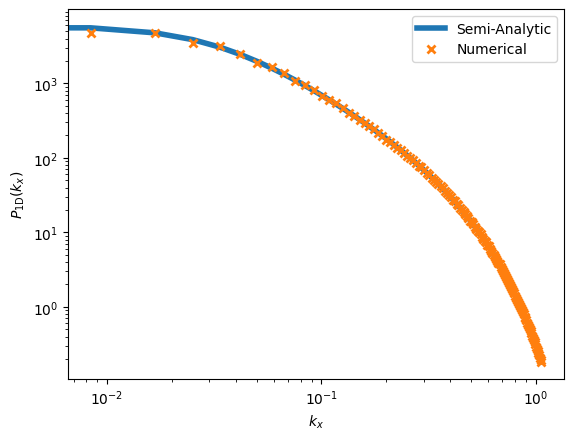

In [11]:
fig, ax = plt.subplots()
ax.loglog(k_x, P_1D, label="Semi-Analytic", lw=4)
ax.loglog(k_x, P_1Ds, 'x', label="Numerical", mew=2)
ax.legend()
ax.set_xlabel("$k_x$")
ax.set_ylabel(r"$P_{\rm 1D}(k_x)$")